# 📊 BMW Stock Analysis (1996–2024)

Анализ исторических данных акций BMW.  
Цель — изучить динамику цены, доходность и волатильность акции.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

## Step 1 — Data Understanding

На этом этапе мы знакомимся с датасетом:
- загружаем данные
- изучаем структуру
- смотрим базовую статистику

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mhassansaboor/bmw-stock-data-1996-2024/BMW_Data.csv')
df.head()

,Date,Adj_Close,Close,High,Low,Open,Volume
0,1996-11-08,8.100290,18.171000,18.209999,18.171000,18.209999,767000
1,1996-11-11,8.078445,18.122000,18.200001,18.082001,18.190001,260000
2,1996-11-12,8.139520,18.259001,18.327999,18.091999,18.160999,1066000
3,1996-11-13,8.126592,18.230000,18.344000,18.190001,18.344000,793000
4,1996-11-14,8.152893,18.289000,18.289000,18.132000,18.205000,351000


Данные содержат ежедневные цены акций BMW начиная с 1996 года.

In [3]:
df.shape

(7212, 7)

Датасет содержит **7212 торговых дней** и **7 колонок**.

In [4]:
df.columns

Index(['Date', 'Adj_Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

Данные включают:
- цены открытия и закрытия
- дневной максимум и минимум
- скорректированную цену
- объём торгов

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7212 entries, 0 to 7211
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       7212 non-null   object 
 1   Adj_Close  7212 non-null   float64
 2   Close      7212 non-null   float64
 3   High       7212 non-null   float64
 4   Low        7212 non-null   float64
 5   Open       7212 non-null   float64
 6   Volume     7212 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 394.5+ KB


В датасете отсутствуют пропуски.  
Однако колонка **Date имеет тип object**, её нужно преобразовать в формат даты.

In [6]:
df.describe()

,Adj_Close,Close,High,Low,Open,Volume
count,7212.000000,7212.000000,7212.000000,7212.000000,7212.000000,7.212000e+03
mean,36.020199,56.427535,57.111143,55.720695,56.446728,2.107946e+06
std,23.641099,25.245886,25.415148,25.055661,25.252263,1.467180e+06
min,8.065074,17.040001,17.815001,16.000000,17.280001,0.000000e+00
25%,16.443254,34.457500,34.900002,33.887500,34.465001,1.194308e+06
50%,26.329212,49.372501,50.094999,48.752501,49.267500,1.793778e+06
75%,53.329208,79.332500,80.105000,78.342497,79.379997,2.636572e+06
max,108.059044,122.599998,123.750000,120.349998,123.300003,2.871954e+07


### 📌 Базовая статистика

- Средняя цена закрытия акции BMW ≈ **56 €**
- Минимальная цена ≈ **17 €**
- Максимальная цена ≈ **123 €**
- Это показывает сильный рост акции в долгосрочной перспективе
- Стандартное отклонение ≈ **25 €**, что говорит о заметной волатильности
- Средний объём торгов ≈ **2.1 млн акций в день**

## Step 2 — Data Cleaning & Preparation

Подготовим данные для анализа временных рядов.

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7212 entries, 0 to 7211
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       7212 non-null   datetime64[ns]
 1   Adj_Close  7212 non-null   float64       
 2   Close      7212 non-null   float64       
 3   High       7212 non-null   float64       
 4   Low        7212 non-null   float64       
 5   Open       7212 non-null   float64       
 6   Volume     7212 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 394.5 KB


Колонка Date преобразована в формат datetime.

In [9]:
df = df.sort_values('Date')

In [10]:
df.head()

,Date,Adj_Close,Close,High,Low,Open,Volume
0,1996-11-08,8.100290,18.171000,18.209999,18.171000,18.209999,767000
1,1996-11-11,8.078445,18.122000,18.200001,18.082001,18.190001,260000
2,1996-11-12,8.139520,18.259001,18.327999,18.091999,18.160999,1066000
3,1996-11-13,8.126592,18.230000,18.344000,18.190001,18.344000,793000
4,1996-11-14,8.152893,18.289000,18.289000,18.132000,18.205000,351000


In [11]:
df.tail()

,Date,Adj_Close,Close,High,Low,Open,Volume
7207,2024-12-19,77.279999,77.279999,78.379997,76.900002,77.080002,1297262
7208,2024-12-20,77.580002,77.580002,77.860001,76.120003,76.699997,2000177
7209,2024-12-23,76.940002,76.940002,77.680000,76.260002,77.620003,642208
7210,2024-12-27,78.339996,78.339996,78.459999,76.739998,76.879997,958948
7211,2024-12-30,78.980003,78.980003,79.040001,77.839996,77.919998,456155


Данные отсортированы по дате от старых к новым.

In [12]:
df.set_index('Date', inplace=True)

In [13]:
df.head()

,Adj_Close,Close,High,Low,Open,Volume
Date,,,,,,
1996-11-08,8.100290,18.171000,18.209999,18.171000,18.209999,767000
1996-11-11,8.078445,18.122000,18.200001,18.082001,18.190001,260000
1996-11-12,8.139520,18.259001,18.327999,18.091999,18.160999,1066000
1996-11-13,8.126592,18.230000,18.344000,18.190001,18.344000,793000
1996-11-14,8.152893,18.289000,18.289000,18.132000,18.205000,351000


Дата установлена в качестве индекса.
Теперь данные готовы для анализа временных рядов.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7212 entries, 1996-11-08 to 2024-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj_Close  7212 non-null   float64
 1   Close      7212 non-null   float64
 2   High       7212 non-null   float64
 3   Low        7212 non-null   float64
 4   Open       7212 non-null   float64
 5   Volume     7212 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 394.4 KB


Дата успешно установлена в качестве индекса (DatetimeIndex).  
Данные полностью готовы для анализа временных рядов.

## Step 3 — Price Trend Over Time

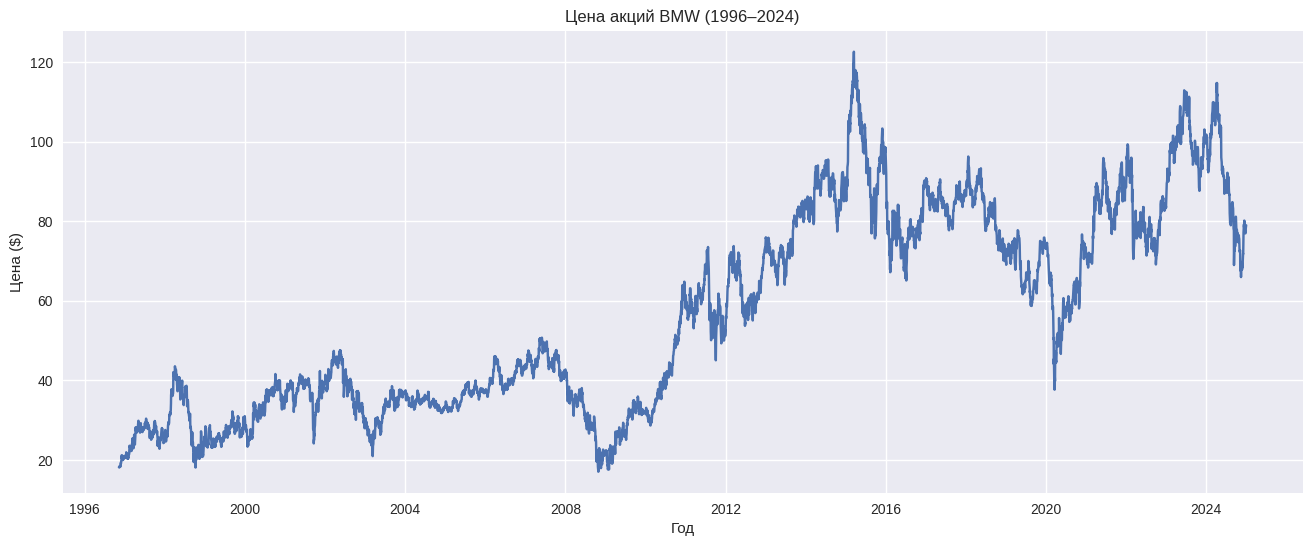

In [15]:
plt.figure(figsize=(16,6))

plt.plot(df['Close'])

plt.title("Цена акций BMW (1996–2024)")
plt.xlabel("Год")
plt.ylabel("Цена ($)")

plt.show()

In [16]:
df['Daily_Return'] = df['Adj_Close'].pct_change()
df['MA30'] = df['Adj_Close'].rolling(window=30).mean()
df['MA200'] = df['Adj_Close'].rolling(window=200).mean()

Первые 200 строк содержат пропуски в колонках MA, так как расчет требует исторического окна в 200 дней

In [17]:
df['Year'] = df.index.year
df['Month'] = df.index.month

Text(0.5, 1.0, 'Распределение дневной доходности BMW')

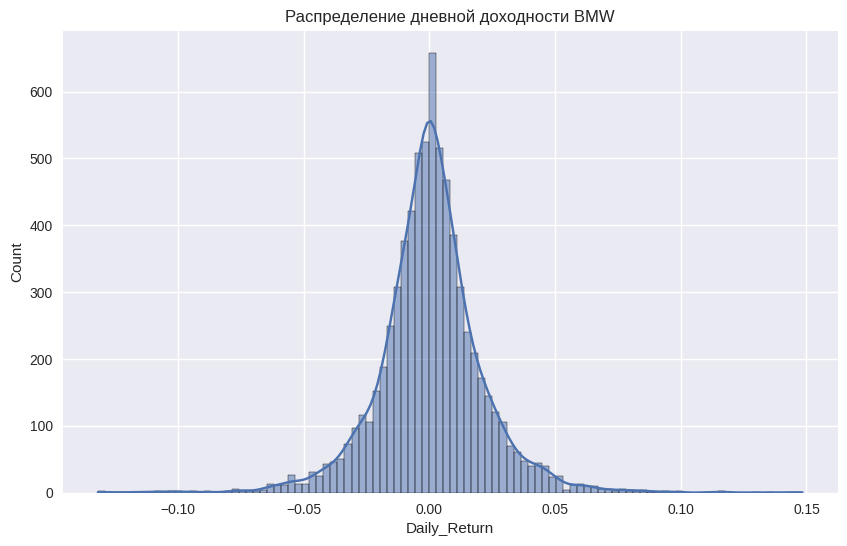

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True)
plt.title("Распределение дневной доходности BMW")

Интерпретация распределения:

Распределение имеет «высокий пик» вокруг нуля. Это значит, что в большинство дней цена акции BMW меняется незначительно.

Мы видим «толстые хвосты» (выбросы за пределы -5% и +5%). Это дни экстремальной волатильности, которые важно изучить отдельно (например, кризисы 2008 или 2020 годов).

Text(0.5, 1.0, 'Связь Объема торгов и Доходности')

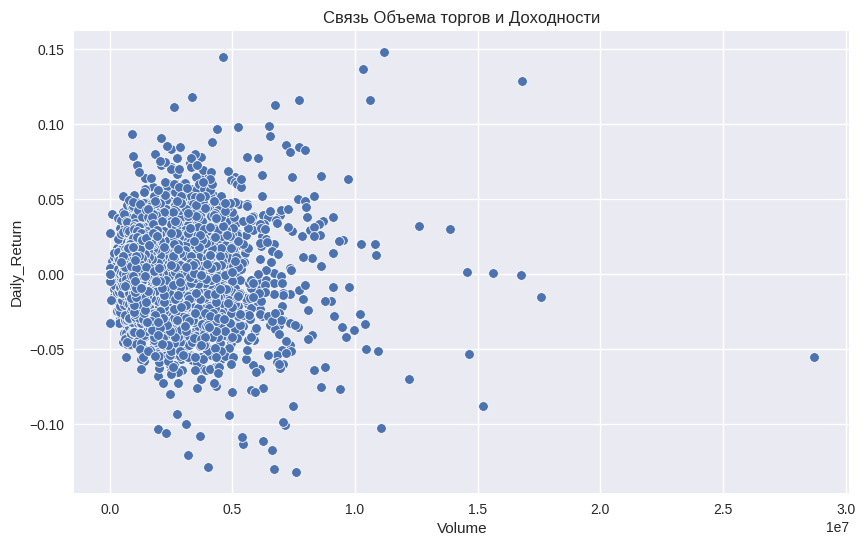

In [19]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Volume', y='Daily_Return')
plt.title("Связь Объема торгов и Доходности")

Анализ связи объема и цены:

На графике видна форма «воронки» или «облака».

Заметно, что экстремальные изменения цены (высокая доходность или глубокое падение) часто сопровождаются повышенным объемом торгов. Это подтверждает гипотезу: значимые новости вызывают всплеск активности инвесторов.

In [20]:
df.to_csv('bmw_cleaned.csv')